<h1>A CNN trained on fashion MNIST dataset</h1>
<h2>By Hamoun Enayati</h2>
<hr>
<p>The Fashion MNIST dataset consists of 1000 train and 1000 test pictures of size (28,28), each one belonging to one of the following 10 classes:</p>
<ol start = '0'>
    <li>T-shirt/top</li>
    <li>Trouser</li>
    <li>Pullover</li>
    <li>Dress</li>
    <li>Coat</li>
    <li>Sandal</li>
    <li>Shirt</li>
    <li>Sneaker</li>
    <li>Bag</li>
    <li>Ankle Boot</li>
</ol>
<hr>

In [1]:
import numpy as np
import tensorflow as tf
from tensorflow.keras import layers
import matplotlib.pyplot as plt
import pandas as pd

In [2]:
Categories ={
    0: 'T-shirt/top',
    1: 'Trouser',
    2: 'Pullover',
    3: 'Dress',
    4: 'Coat',
    5: 'Sandal',
    6: 'Shirt',
    7: 'Sneaker',
    8: 'Bag',
    9: 'Ankle Boot'  
}

<h3>Loading Data</h3>
<hr>

In [3]:
train_data = pd.read_csv('fashion/fashion_train.csv')
train_data.head()

,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,...,V776,V777,V778,V779,V780,V781,V782,V783,V784,y
0,0,0,0,0,0,0,0,0,0,22,...,0,0,1,0,0,3,0,0,0,6
1,0,0,0,0,0,0,0,0,0,0,...,0,0,91,97,80,78,0,0,0,9
2,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,9
3,0,0,0,0,0,0,0,0,1,2,...,0,0,0,0,0,0,0,0,0,4
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1


In [4]:
X_train = train_data.iloc[:, :-1]
X_train = np.array(X_train).reshape((len(X_train), 28,28, 1))
y_train = np.array(pd.get_dummies(train_data.iloc[:, -1]), dtype = np.int8)

In [5]:
test_data = pd.read_csv('fashion/fashion_test.csv')
X_test = test_data.iloc[:, :-1]
X_test = np.array(X_test).reshape(len(X_test), 28,28,1)
y_test = np.array(pd.get_dummies(test_data.iloc[:, -1]), dtype = np.int8)

<h3>Model</h3>
<hr>

In [6]:
model = tf.keras.Sequential([
    layers.Conv2D(10, (3,3), input_shape = (28,28,1), activation = 'relu'),
    layers.MaxPooling2D(2,2),
    layers.Dropout(0.25),

    layers.Conv2D(10, (3,3), activation = 'relu'),
    layers.MaxPooling2D(2,2),
    layers.Dropout(0.25),


    layers.Flatten(),
    layers.Dense(128, activation = 'sigmoid'),
    layers.Dropout(0.25),
    layers.Dense(128, activation = 'sigmoid'),
    layers.Dropout(0.5),
    layers.Dense(128, activation = 'sigmoid'),
    layers.Dropout(0.25),
    layers.Dense(10, activation = 'softmax')
])

d:\Annaconda3\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [7]:
model.compile(optimizer = 'adam', loss = 'categorical_crossentropy', metrics = ['accuracy'])
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 26, 26, 10)     │           100 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 13, 13, 10)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 13, 13, 10)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 11, 11, 10)     │           910 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 5, 5, 10)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 5, 5, 10)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 250)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │        32,128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 67,452 (263.48 KB)

 Trainable params: 67,452 (263.48 KB)

 Non-trainable params: 0 (0.00 B)

<h3>Training</h3>
<hr>

In [8]:
model.fit(X_train, y_train, epochs = 200, validation_split= 0.2)

Epoch 1/200
25/25 ━━━━━━━━━━━━━━━━━━━━ 2s 15ms/step - accuracy: 0.1100 - loss: 2.3749 - val_accuracy: 0.1200 - val_loss: 2.3053
Epoch 2/200
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.1150 - loss: 2.3528 - val_accuracy: 0.1400 - val_loss: 2.2520
Epoch 3/200
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.1262 - loss: 2.3332 - val_accuracy: 0.1650 - val_loss: 2.2223
Epoch 4/200
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.1500 - loss: 2.2790 - val_accuracy: 0.2900 - val_loss: 2.1699
Epoch 5/200
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.1838 - loss: 2.2199 - val_accuracy: 0.2650 - val_loss: 2.0688
Epoch 6/200
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.1900 - loss: 2.1403 - val_accuracy: 0.3550 - val_loss: 1.9411
Epoch 7/200
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.2412 - loss: 2.0159 - val_accuracy: 0.3500 - val_loss: 1.8143
Epoch 8/200
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.2625 - loss: 1.8822 - val_accuracy: 0.4200 -

<h3>Evaluation</h3>
<hr>

In [9]:
model.evaluate(X_test, y_test)

32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8070 - loss: 0.5726


[0.5725536346435547, 0.8069999814033508]

<h3>Some Examples</h3>
<hr>

In [10]:
y_ = model.predict(X_test)

32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step


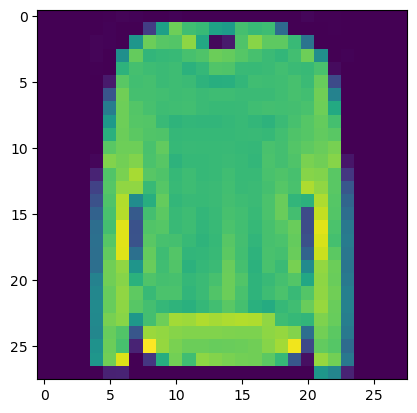

In [11]:
plt.imshow(X_test[0])

In [12]:
print(f'prediction: {Categories[np.argmax(y_[0])]}')
print(f'real: {Categories[np.argmax(y_test[0])]}')

prediction: Pullover
real: Pullover


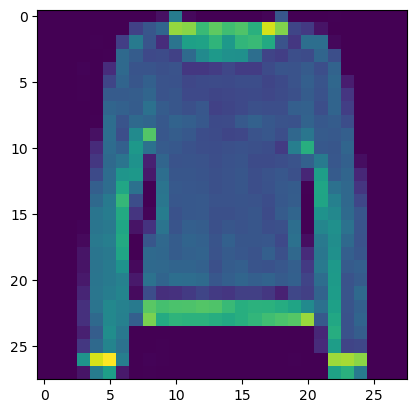

In [13]:
plt.imshow(X_test[1])

In [14]:
print(f'prediction: {Categories[np.argmax(y_[1])]}')
print(f'real: {Categories[np.argmax(y_test[1])]}')

prediction: Pullover
real: Pullover


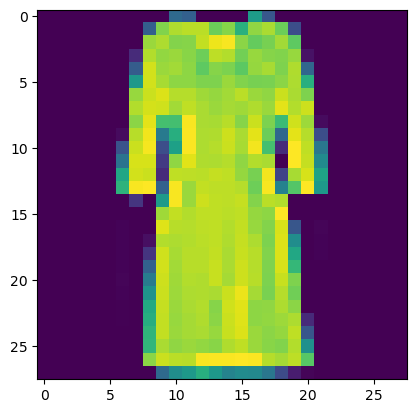

In [15]:
plt.imshow(X_test[2])

In [16]:
print(f'prediction: {Categories[np.argmax(y_[2])]}')
print(f'real: {Categories[np.argmax(y_test[2])]}')

prediction: Dress
real: Dress


<h3>Confusion Matrix</h3>
<hr>

In [17]:
from sklearn.metrics import confusion_matrix

In [18]:
y_test_category = np.array([np.argmax(y_test[i]) for i in range(len(y_test))])
y_pred_category = np.array([np.argmax(y_[i]) for i in range(len(y_))])

In [19]:
confusion_matrix(y_test_category, y_pred_category)

array([[ 69,   0,   6,   5,   1,   0,  10,   0,   0,   0],
       [  0,  86,   0,   4,   2,   0,   0,   0,   0,   0],
       [  1,   0,  81,   2,   6,   0,   1,   0,   0,   0],
       [  3,   0,   0,  89,   7,   0,   5,   0,   1,   0],
       [  1,   0,  17,   6,  73,   0,   2,   0,   0,   0],
       [  0,   0,   0,   1,   0,  93,   0,   6,   0,   5],
       [ 21,   0,  37,   3,  20,   0,  14,   0,   4,   0],
       [  0,   0,   0,   0,   0,   2,   0,  87,   0,   5],
       [  0,   0,   0,   1,   1,   0,   0,   1, 112,   0],
       [  0,   0,   0,   0,   0,   0,   0,   6,   0, 103]])